In [ ]:
import cv2
from ultralytics import YOLO
import easyocr
import os
import numpy as np
from datetime import datetime
from IPython.display import clear_output, display, Image
import matplotlib.pyplot as plt

print("✅ Libraries imported")

In [ ]:
import cv2

# ================== CHANGE THIS ==================
video_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\WhatsApp Video 2026-04-28 at 16.32.32.mp4"   # ← Put your actual video file name/path here
# ================================================

cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("❌ Error: Could not open the video file!")
    print("Check if the file path is correct and the file is not corrupted.")
else:
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration_sec = total_frames / fps if fps > 0 else 0

    print("✅ Video Information:")
    print(f"Total Number of Frames : {total_frames:,}")
    print(f"FPS                    : {fps:.2f}")
    print(f"Duration               : {duration_sec:.2f} seconds ({duration_sec/60:.2f} minutes)")

cap.release()

In [ ]:
pip install --upgrade mistralai

In [ ]:
"""
Vehicle / Shipping Container Detector  (no mistralai SDK — uses requests)
==========================================================================
1. Opens a video file with OpenCV
2. Extracts the first 10 frames
3. Encodes each frame as base64 JPEG
4. Sends every frame to Mistral Pixtral via raw HTTP (no SDK needed)
5. Prints a per-frame result + final verdict

Requirements:
    pip install opencv-python requests
    (NO mistralai package needed)
"""

import cv2
import base64
import json
import sys
import requests
from pathlib import Path

# ─────────────────────────────────────────────
#  CONFIGURATION  ← Edit these two lines only
# ─────────────────────────────────────────────
VIDEO_PATH      = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\WhatsApp Video 2026-04-28 at 16.32.32.mp4"
MISTRAL_API_KEY = "XZrK8S4UUomwXBgewOckRihF0EOqx7vu"
   # ← paste your key here
# ───────────────────────────────────────────
MODEL= "mistral-large-latest"

NUM_FRAMES   = 10
JPEG_QUALITY = 85
API_URL      = "https://api.mistral.ai/v1/chat/completions"

DETECTION_PROMPT = (
    "You are a world-class multimodal AI analyst. Describe this image comprehensively.\n\n"
    
    "Return ONLY valid JSON with this structure:\n"
    "{\n"
    '  "summary": "One sentence scene description",\n'
    '  "main_objects": ["list of main things like truck, container, crane, etc."],\n'
    '  "detailed_detections": [\n'
    '    {"object": "blue shipping container", "location": "center-right", "state": "on truck"},\n'
    '    {"object": "white truck", "location": "foreground", "state": "moving"}\n'
    "  ],\n"
    '  "vehicles": ["list all vehicles"],\n'
    '  "containers": ["list all shipping containers with colors"],\n'
    '  "people": ["number and description"],\n'
    '  "environment": "port / highway / warehouse / etc."\n'
    "}"
)


# ─────────────────────────────────────────────
#  HELPERS
# ─────────────────────────────────────────────

def frame_to_base64(frame) -> str:
    encode_params = [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY]
    success, buffer = cv2.imencode(".jpg", frame, encode_params)
    if not success:
        raise RuntimeError("Failed to JPEG-encode frame")
    return base64.standard_b64encode(buffer).decode("utf-8")


def analyze_frame(b64_image: str, frame_idx: int) -> dict:
    headers = {
        "Authorization": f"Bearer {MISTRAL_API_KEY}",
        "Content-Type": "application/json",
    }
    payload = {
        "model": MODEL,
        "messages": [
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/jpeg;base64,{b64_image}"},
                    },
                    {"type": "text", "text": DETECTION_PROMPT},
                ],
            }
        ],
    }

    response = requests.post(API_URL, headers=headers, json=payload, timeout=60)

    if response.status_code != 200:
        raise RuntimeError(
            f"Mistral API error {response.status_code}: {response.text[:300]}"
        )

    raw_text = response.json()["choices"][0]["message"]["content"].strip()

    if raw_text.startswith("```"):
        raw_text = raw_text.strip("`").lstrip("json").strip()

    try:
        result = json.loads(raw_text)
    except json.JSONDecodeError:
        result = {
            "container_present": None,
            "confidence": "unknown",
            "reasoning": raw_text[:200],
        }

    result["frame_index"] = frame_idx
    return result


# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────

def main():
    cap = cv2.VideoCapture(VIDEO_PATH)
    if not cap.isOpened():
        print("❌  Error: Could not open the video file!")
        print(f"    Path checked: {VIDEO_PATH}")
        sys.exit(1)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS)
    duration_sec = total_frames / fps if fps > 0 else 0

    print("=" * 60)
    print("  ✅  Video Information")
    print("=" * 60)
    print(f"  File            : {Path(VIDEO_PATH).name}")
    print(f"  Total Frames    : {total_frames:,}")
    print(f"  FPS             : {fps:.2f}")
    print(f"  Duration        : {duration_sec:.2f}s  ({duration_sec/60:.2f} min)")
    print("=" * 60)

    actual_count   = min(NUM_FRAMES, total_frames)
    target_indices = list(range(actual_count))

    print(f"\n📸  Extracting frames: {target_indices}")

    frames = {}
    for idx in target_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames[idx] = frame
        else:
            print(f"    ⚠️  Could not read frame {idx} — skipping")

    cap.release()
    print(f"    → Successfully extracted {len(frames)} frame(s)\n")

    if MISTRAL_API_KEY == "YOUR_MISTRAL_API_KEY":
        print("❌  Please set your MISTRAL_API_KEY at the top of the script.")
        sys.exit(1)

    print("=" * 60)
    print("  🔍  Sending frames to Mistral Pixtral …")
    print("=" * 60)

    results = []
    for frame_idx, frame in frames.items():
        print(f"\n  Frame {frame_idx:>3} │ encoding … ", end="", flush=True)
        b64 = frame_to_base64(frame)
        print("sending … ", end="", flush=True)

        try:
            result = analyze_frame(b64, frame_idx)
        except RuntimeError as e:
            print(f"\n  ❌  {e}")
            result = {
                "frame_index": frame_idx,
                "container_present": None,
                "confidence": "error",
                "reasoning": str(e),
            }

        results.append(result)
        icon = "🟢" if result.get("container_present") is True else (
               "🔴" if result.get("container_present") is False else "⚪")
        print(
            f"done.\n"
            f"         {icon}  container_present = {result.get('container_present')}"
            f"  │  confidence = {result.get('confidence')}\n"
            f"         💬  {result.get('reasoning')}"
        )

    valid      = [r for r in results if r.get("container_present") is not None]
    detections = [r for r in valid   if r.get("container_present") is True]
    rate       = len(detections) / len(valid) * 100 if valid else 0

    print("\n" + "=" * 60)
    print("  📊  FINAL VERDICT")
    print("=" * 60)
    print(f"  Frames analysed       : {len(results)}")
    print(f"  Frames with container : {len(detections)} / {len(valid)}  ({rate:.0f}%)")

    if rate >= 50:
        verdict = "✅  CONTAINER DETECTED  — A container is present in the video."
    elif rate > 0:
        verdict = "⚠️  POSSIBLY PRESENT  — Container visible in some frames only."
    else:
        verdict = "❌  NO CONTAINER  — No container found in any sampled frame."

    print(f"\n  {verdict}\n")

    out_path = Path(VIDEO_PATH).parent / "container_detection_results.json"
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)
    print(f"  📄  Full results saved to: {out_path}")
    print("=" * 60)


if __name__ == "__main__":
    main()

In [ ]:
import os
from ollama import Client
api_key = "860f7ab51d314adbba421c5595a07768.MM8qu_KRUnJ4AAL1EoFrR4ME"
client = Client(
    host="https://ollama.com",
    headers={"Authorization": f"Bearer {api_key}"}
)
messages = [
  {
    'role': 'user',
    'content': 'Why is the sky blue?',
  },
]

for part in client.chat('kimi-k2.5:cloud', messages=messages, stream=True):
  print(part['message']['content'], end='', flush=True)

In [ ]:
import cv2
from ultralytics import YOLO
import os
from datetime import timedelta

# ====================== SETTINGS ======================
           # ← CHANGE TO YOUR ACTUAL VIDEO FILE
model_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\yolo11s.pt"               # You can change to yolo11m.pt later

output_folder = "detected_frames"
skip_seconds = 5                        # Process every 5 seconds
conf_threshold = 0.5
# =====================================================

# Create output folder
os.makedirs(output_folder, exist_ok=True)

# Load model
model = YOLO(model_path)

# Open video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video FPS: {fps}")
print(f"Total Frames: {total_frames}")
print(f"Processing 1 frame every {skip_seconds} seconds...\n")

frame_count = 0
processed_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # Calculate current time in seconds
    current_time_sec = frame_count / fps

    # Process only when 5 seconds interval reached
    if current_time_sec >= processed_count * skip_seconds:
        
        processed_count += 1
        
        # Resize for faster processing
        frame_resized = cv2.resize(frame, (640, 640))

        # Run detection + tracking
        results = model.track(frame_resized, conf=conf_threshold, 
                            tracker="bytetrack.yaml", persist=True)

        # Draw results on frame
        annotated_frame = results[0].plot()

        # Save original frame
        frame_filename = f"{output_folder}/frame_{processed_count:04d}_{current_time_sec:.1f}s.jpg"
        cv2.imwrite(frame_filename, frame)

        # Save annotated frame (with bounding boxes)
        annotated_filename = f"{output_folder}/frame_{processed_count:04d}_{current_time_sec:.1f}s_annotated.jpg"
        cv2.imwrite(annotated_filename, annotated_frame)

        # Print detection summary
        num_trucks = len([r for r in results[0].boxes if r.cls == 2])  # assuming class 2 is truck (we'll fix later)
        print(f"✅ Processed at {str(timedelta(seconds=int(current_time_sec)))} | "
              f"Trucks detected: {num_trucks} | Saved frame {processed_count}")

    # Optional: Show progress (you can comment this if running in background)
    if frame_count % 500 == 0:
        print(f"Progress: {frame_count}/{total_frames} frames read...")

print("\n🎉 Processing Completed!")
print(f"Total frames processed: {processed_count}")
print(f"All frames and results saved in folder: '{output_folder}'")

cap.release()

In [ ]:
import cv2
from ultralytics import YOLO
import os
from datetime import timedelta

# ====================== SETTINGS ======================
video_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\WhatsApp Video 2026-04-28 at 16.32.32.mp4"           # ← CHANGE THIS TO YOUR VIDEO FILE NAME

input_folder = "input_frames"           # Original frames
detection_folder = "detection_results"  # Frames with detection boxes

skip_seconds = 5                        # Process every 5 seconds
conf_threshold = 0.5
model_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\yolo11s.pt"               # Change to yolo11m.pt if needed
# =====================================================

# Create folders
os.makedirs(input_folder, exist_ok=True)
os.makedirs(detection_folder, exist_ok=True)

# Load model
model = YOLO(model_path)

# Open video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video FPS: {fps:.2f}")
print(f"Total Frames: {total_frames}")
print(f"Processing 1 frame every {skip_seconds} seconds...\n")

frame_count = 0
processed_count = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # Process frame every 5 seconds
    current_time_sec = frame_count / fps

    if current_time_sec >= processed_count * skip_seconds:
        
        processed_count += 1
        time_str = f"{int(current_time_sec//60):02d}m_{int(current_time_sec%60):02d}s"

        # Resize for faster processing
        frame_resized = cv2.resize(frame, (640, 640))

        # Run detection
        results = model.track(frame_resized, conf=conf_threshold, 
                            tracker="bytetrack.yaml", persist=True)

        # === Save Original Frame ===
        original_filename = f"{input_folder}/frame_{processed_count:04d}_{time_str}.jpg"
        cv2.imwrite(original_filename, frame)

        # === Save Detection Result ===
        annotated_frame = results[0].plot()
        detected_filename = f"{detection_folder}/detected_{processed_count:04d}_{time_str}.jpg"
        cv2.imwrite(detected_filename, annotated_frame)

        # Print status
        print(f"✅ {time_str} | Frame {processed_count:04d} | "
              f"Saved in input_frames & detection_results")

    # Show simple progress
    if frame_count % 900 == 0:   # Every 30 seconds
        print(f"Progress: {frame_count}/{total_frames} frames read...")

print("\n🎉 Processing Completed Successfully!")
print(f"Total frames processed : {processed_count}")
print(f"Original frames saved in : ./{input_folder}/")
print(f"Detection results saved in: ./{detection_folder}/")

cap.release()

In [2]:
import cv2
import os

# ====================== SETTINGS ======================
video_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\WhatsApp Video 2026-04-28 at 16.32.32.mp4"

input_folder = "input_frames"           # Original frames only

skip_seconds = 10                       # Save frame every 3 seconds
# =====================================================

# Create folder
os.makedirs(input_folder, exist_ok=True)

# Open video
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video FPS: {fps:.2f}")
print(f"Total Frames: {total_frames}")
print(f"Saving 1 frame every {skip_seconds} seconds...\n")

frame_count = 0
saved_count = 0
last_saved_time = -skip_seconds

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    current_time_sec = frame_count / fps

    # Save frame every 3 seconds
    if current_time_sec >= last_saved_time + skip_seconds:
        
        last_saved_time = current_time_sec
        saved_count += 1
        time_str = f"{int(current_time_sec//60):02d}m_{int(current_time_sec%60):02d}s"

        # Save original frame only
        filename = f"{input_folder}/frame_{saved_count:04d}_{time_str}.jpg"
        cv2.imwrite(filename, frame)

        print(f"✅ {time_str} | Frame {saved_count:04d} (Frame #{frame_count}) | Saved: {filename}")

    # Show progress
    if frame_count % (fps * 10) == 0:   # Every 10 seconds
        print(f"Progress: {frame_count}/{total_frames} frames read ({frame_count/fps:.1f} seconds)")

print("\n🎉 Processing Completed Successfully!")
print(f"Total frames saved: {saved_count}")
print(f"Frames saved in: ./{input_folder}/")

cap.release()

Video FPS: 30.00
Total Frames: 9048
Saving 1 frame every 10 seconds...

✅ 00m_00s | Frame 0001 (Frame #1) | Saved: input_frames/frame_0001_00m_00s.jpg
✅ 00m_10s | Frame 0002 (Frame #301) | Saved: input_frames/frame_0002_00m_10s.jpg
✅ 00m_20s | Frame 0003 (Frame #601) | Saved: input_frames/frame_0003_00m_20s.jpg
✅ 00m_30s | Frame 0004 (Frame #901) | Saved: input_frames/frame_0004_00m_30s.jpg
✅ 00m_40s | Frame 0005 (Frame #1201) | Saved: input_frames/frame_0005_00m_40s.jpg
✅ 00m_50s | Frame 0006 (Frame #1501) | Saved: input_frames/frame_0006_00m_50s.jpg
✅ 01m_00s | Frame 0007 (Frame #1801) | Saved: input_frames/frame_0007_01m_00s.jpg
✅ 01m_10s | Frame 0008 (Frame #2101) | Saved: input_frames/frame_0008_01m_10s.jpg
✅ 01m_20s | Frame 0009 (Frame #2401) | Saved: input_frames/frame_0009_01m_20s.jpg
✅ 01m_30s | Frame 0010 (Frame #2701) | Saved: input_frames/frame_0010_01m_30s.jpg
✅ 01m_40s | Frame 0011 (Frame #3001) | Saved: input_frames/frame_0011_01m_40s.jpg
✅ 01m_50s | Frame 0012 (Frame #3

In [ ]:
from ultralytics import YOLO

# Load a pretrained classification model
model = YOLO("yolo26n-cls.pt")  # or yolo26s-cls.pt, etc.

# Predict on an image
results = model(r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\input_frames\frame_0001_00m_00s.jpg")  # Returns top classes with confidence

In [ ]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt

# ================== CONFIGURATION ==================
image_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\input_frames\frame_0001_00m_00s.jpg"

# Model path - Change this to your trained model
model_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\yolo26n-cls.pt"   # Put your best.pt in the current folder or give full path

# Output settings
output_dir = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "frame_0001_00m_00s_detected.jpg")
# ===================================================

# Load the model
print("🚀 Loading YOLO model...")
model = YOLO(model_path)

# Run detection
print("🔍 Running detection...")
results = model(image_path, conf=0.4, iou=0.45, verbose=False)

# Get annotated image
annotated_img = results[0].plot()

# Save the detected image
cv2.imwrite(output_path, annotated_img)
print(f"✅ Image successfully saved at:\n{output_path}")

# ================== DISPLAY IN JUPYTER ==================
# Convert BGR to RGB for matplotlib
annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 9))
plt.imshow(annotated_rgb)
plt.title("Vehicle Plate Detection - frame_0001_00m_00s.jpg", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# ================== OPTIONAL: Save Cropped Plates ==================
# Uncomment the code below if you want to save cropped license plates



In [7]:
import cv2
import numpy as np
from ultralytics import YOLO
import os

# ============================================
# CONFIG — change these two paths only
# ============================================
IMAGE_PATH  = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\frames\frame_0001_00m_00s.jpg"
OUTPUT_PATH = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames\detected.jpg"

# ============================================
# PROMPTS
# ============================================
prompts = [
    "truck with shipping container",
    "semi truck carrying container",
    "loaded container truck",
    "empty truck chassis",
    "semi truck without container",
    "bare truck trailer frame",
    "empty flatbed chassis",
    "truck chassis frame",
    "intermodal chassis",
    "skeletal trailer",
    "shipping container",
    "iso container",
    "white shipping container",
    "worker",
    "person in orange vest",
    "ground crew",
]

LOADED_LABELS = {
    "truck with shipping container",
    "semi truck carrying container",
    "loaded container truck",
}
EMPTY_LABELS = {
    "empty truck chassis",
    "semi truck without container",
    "bare truck trailer frame",
    "empty flatbed chassis",
    "truck chassis frame",
    "intermodal chassis",
    "skeletal trailer",
}
CONTAINER_LABELS = {
    "shipping container",
    "iso container",
    "white shipping container",
}
PERSON_LABELS = {
    "worker",
    "person in orange vest",
    "ground crew",
}

# Colors BGR
COLOR_LOADED    = (0,   0,   255)
COLOR_EMPTY     = (0,   255,   0)
COLOR_CONTAINER = (0,   165, 255)
COLOR_PERSON    = (255,   0, 255)
COLOR_DEFAULT   = (200, 200, 200)

# ============================================
# LOAD MODEL
# ============================================
print("=" * 60)
print("  Truck Container Detection — VS Code")
print("=" * 60)
print("\n[1/3] Loading YOLOE model...")
model = YOLO("yoloe-26x-seg.pt")
model.set_classes(prompts)
print(f"      Model loaded. {len(prompts)} prompts set.")

# ============================================
# READ IMAGE
# ============================================
print(f"\n[2/3] Reading image...")
print(f"      Path: {IMAGE_PATH}")

frame = cv2.imread(IMAGE_PATH)

if frame is None:
    print(f"\n  ERROR: Cannot read image at:\n  {IMAGE_PATH}")
    print("  Check the path is correct and the file exists.")
    input("\nPress Enter to exit...")
    exit()

height, width = frame.shape[:2]
print(f"      Resolution: {width} x {height} px")

# ============================================
# RUN DETECTION
# ============================================
print(f"\n[3/3] Running detection...")
results = model.predict(frame, conf=0.20, verbose=False)
result  = results[0]

# ============================================
# PARSE DETECTIONS
# ============================================
loaded_found    = False
empty_found     = False
container_found = False
person_found    = False
detected        = []

if result.boxes is not None and len(result.boxes) > 0:
    for box in result.boxes:
        label = prompts[int(box.cls)]
        conf  = float(box.conf)
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        if label in LOADED_LABELS:
            loaded_found = True
            cat   = "LOADED TRUCK"
            color = COLOR_LOADED
        elif label in EMPTY_LABELS:
            empty_found = True
            cat   = "EMPTY TRUCK"
            color = COLOR_EMPTY
        elif label in CONTAINER_LABELS:
            container_found = True
            cat   = "CONTAINER"
            color = COLOR_CONTAINER
        elif label in PERSON_LABELS:
            person_found = True
            cat   = "PERSON"
            color = COLOR_PERSON
        else:
            cat   = "OTHER"
            color = COLOR_DEFAULT

        detected.append({
            "label": label,
            "cat":   cat,
            "conf":  conf,
            "color": color,
            "box":   (x1, y1, x2, y2),
        })

# ============================================
# BUILD STATUS
# ============================================
if loaded_found and empty_found:
    status_text  = "MIXED: LOADED + EMPTY TRUCKS DETECTED"
    status_color = (0, 200, 255)
elif loaded_found:
    status_text  = "LOADED TRUCK — Container Mounted"
    status_color = COLOR_LOADED
elif empty_found:
    status_text  = "EMPTY TRUCK — No Container"
    status_color = COLOR_EMPTY
elif container_found:
    status_text  = "CONTAINER DETECTED — No Truck"
    status_color = COLOR_CONTAINER
else:
    status_text  = "NO TRUCK DETECTED"
    status_color = (200, 200, 200)

loaded_list    = [d for d in detected if d["cat"] == "LOADED TRUCK"]
empty_list     = [d for d in detected if d["cat"] == "EMPTY TRUCK"]
container_list = [d for d in detected if d["cat"] == "CONTAINER"]
person_list    = [d for d in detected if d["cat"] == "PERSON"]

# ============================================
# DRAW ON IMAGE
# ============================================
annotated = result.plot(line_width=2, font_size=0.5)

# ── Top status banner ──
banner_h = 95
cv2.rectangle(annotated, (0, 0), (width, banner_h), (15, 15, 15), -1)

cv2.putText(annotated, status_text,
            (14, 48), cv2.FONT_HERSHEY_SIMPLEX, 1.0, status_color, 3)

summary_parts = []
if loaded_list:    summary_parts.append("Loaded: "     + str(len(loaded_list)))
if empty_list:     summary_parts.append("Empty: "      + str(len(empty_list)))
if container_list: summary_parts.append("Containers: " + str(len(container_list)))
if person_list:    summary_parts.append("Persons: "    + str(len(person_list)))
summary_parts.append("Total: " + str(len(detected)) + " objects")

cv2.putText(annotated, "   |   ".join(summary_parts) if summary_parts else "Nothing detected",
            (14, 78), cv2.FONT_HERSHEY_SIMPLEX, 0.58, (180, 180, 180), 1)

# ── Custom bounding box labels ──
for d in detected:
    x1, y1, x2, y2 = d["box"]
    color      = d["color"]
    label_text = d["cat"] + "  " + str(round(d["conf"] * 100)) + "%"

    (tw, th), _ = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
    lx = x1
    ly = max(y1 - 28, banner_h + 4)
    cv2.rectangle(annotated, (lx, ly), (lx + tw + 10, ly + th + 8), color, -1)
    cv2.putText(annotated, label_text,
                (lx + 5, ly + th + 3), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 2)

# ── Bottom info bar ──
cv2.rectangle(annotated, (0, height - 36), (width, height), (15, 15, 15), -1)
cv2.putText(annotated,
            "File: " + os.path.basename(IMAGE_PATH) +
            "   |   Detections: " + str(len(detected)) +
            "   |   Conf threshold: 20%",
            (10, height - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (150, 150, 150), 1)

# ============================================
# SAVE IMAGE
# ============================================
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
cv2.imwrite(OUTPUT_PATH, annotated)

# ============================================
# SAVE FULL TEXT REPORT
# ============================================
log_path = OUTPUT_PATH.replace(".jpg", "_results.txt")

with open(log_path, "w") as f:
    f.write("=" * 60 + "\n")
    f.write("  TRUCK CONTAINER DETECTION REPORT\n")
    f.write("=" * 60 + "\n")
    f.write("  Image      : " + IMAGE_PATH + "\n")
    f.write("  Output     : " + OUTPUT_PATH + "\n")
    f.write("  Status     : " + status_text + "\n")
    f.write("  Total      : " + str(len(detected)) + " object(s)\n")
    f.write("=" * 60 + "\n\n")

    for group_name, items in [
        ("LOADED TRUCKS",  loaded_list),
        ("EMPTY TRUCKS",   empty_list),
        ("CONTAINERS",     container_list),
        ("PERSONS",        person_list),
    ]:
        if items:
            f.write(group_name + " — " + str(len(items)) + " found\n")
            f.write("-" * 50 + "\n")
            for i, d in enumerate(items, 1):
                x1, y1, x2, y2 = d["box"]
                f.write("  [" + str(i) + "] Label      : " + d["label"] + "\n")
                f.write("       Confidence : " + str(round(d["conf"] * 100, 1)) + "%\n")
                f.write("       Box        : (" + str(x1) + "," + str(y1) +
                        ") to (" + str(x2) + "," + str(y2) + ")\n")
                f.write("       Size       : " + str(x2 - x1) + " x " +
                        str(y2 - y1) + " px\n\n")
            f.write("\n")

    f.write("SUMMARY COUNTS\n")
    f.write("-" * 50 + "\n")
    f.write("  Loaded Trucks : " + str(len(loaded_list)) + "\n")
    f.write("  Empty Trucks  : " + str(len(empty_list)) + "\n")
    f.write("  Containers    : " + str(len(container_list)) + "\n")
    f.write("  Persons       : " + str(len(person_list)) + "\n")
    f.write("  Total Objects : " + str(len(detected)) + "\n")

# ============================================
# CONSOLE SUMMARY — GROUPED & CLEAN
# ============================================
print("\n" + "=" * 60)
print("  DETECTION RESULTS")
print("=" * 60)
print("  Status  : " + status_text)
print("  Total   : " + str(len(detected)) + " object(s)\n")

for group_name, items in [
    ("LOADED TRUCKS",  loaded_list),
    ("EMPTY TRUCKS",   empty_list),
    ("CONTAINERS",     container_list),
    ("PERSONS",        person_list),
]:
    if items:
        print("  " + group_name + " — " + str(len(items)) + " found")
        print("  " + "-" * 45)
        for i, d in enumerate(items, 1):
            x1, y1, x2, y2 = d["box"]
            print("  [" + str(i) + "] " + d["label"])
            print("       Conf : " + str(round(d["conf"] * 100, 1)) +
                  "%   Box : (" + str(x1) + "," + str(y1) +
                  ") → (" + str(x2) + "," + str(y2) + ")" +
                  "   Size : " + str(x2 - x1) + "x" + str(y2 - y1) + "px")
        print()

print("  COUNTS")
print("  " + "-" * 45)
print("  Loaded Trucks : " + str(len(loaded_list)))
print("  Empty Trucks  : " + str(len(empty_list)))
print("  Containers    : " + str(len(container_list)))
print("  Persons       : " + str(len(person_list)))
print("  Total         : " + str(len(detected)))
print()
print("  Image saved : " + OUTPUT_PATH)
print("  Log saved   : " + log_path)
print("=" * 60)

# ============================================
# SHOW IMAGE IN WINDOW
# ============================================
win_w = min(width,  1400)
win_h = min(height, 900)
cv2.namedWindow("Truck Detection Result", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Truck Detection Result", win_w, win_h)
cv2.imshow("Truck Detection Result", annotated)

print("\n  Window open — press any key to close.")
cv2.waitKey(0)
cv2.destroyAllWindows()
print("\n  Done.")

  Truck Container Detection — VS Code

[1/3] Loading YOLOE model...
      Model loaded. 16 prompts set.

[2/3] Reading image...
      Path: C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\frames\frame_0001_00m_00s.jpg
      Resolution: 1280 x 720 px

[3/3] Running detection...

  DETECTION RESULTS
  Status  : MIXED: LOADED + EMPTY TRUCKS DETECTED
  Total   : 10 object(s)

  LOADED TRUCKS — 3 found
  ---------------------------------------------
  [1] truck with shipping container
       Conf : 64.7%   Box : (1120,44) → (1280,719)   Size : 160x675px
  [2] truck with shipping container
       Conf : 29.9%   Box : (813,108) → (911,170)   Size : 98x62px
  [3] truck with shipping container
       Conf : 22.1%   Box : (40,103) → (621,575)   Size : 581x472px

  EMPTY TRUCKS — 4 found
  ---------------------------------------------
  [1] semi truck without container
       Conf : 54.0%   Box : (40,85) → (827,575)   Size : 787x490px
  [2] empty truck chassis
       Conf : 50.8%  

error: OpenCV(4.10.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1284: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvNamedWindow'


In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os
from pathlib import Path

# ================== CONFIG ==================
image_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\input_frames\frame_0001_00m_00s.jpg"

# List of models you want to test (you can add/remove)
models_to_test = {
    "YOLO26n (Latest)": "yolo26n.pt",
    "YOLO11n": "yolo11n.pt",
    "YOLO11s": "yolo11s.pt",
    "YOLOv8n": "yolov8n.pt",
    "YOLOv8s": "yolov8s.pt",
    "Your Model": "best.pt"               # ← your trained model
}

output_dir = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames\comparison"
os.makedirs(output_dir, exist_ok=True)

conf_threshold = 0.4
# ===========================================

results_dict = {}

print("🚀 Starting detection with multiple models...\n")

for model_name, model_file in models_to_test.items():
    try:
        print(f"Running {model_name}...")
        
        model = YOLO(model_file)
        results = model(image_path, conf=conf_threshold, iou=0.45, verbose=False)
        
        annotated_img = results[0].plot()
        
        # Save individual result
        save_path = os.path.join(output_dir, f"detected_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.jpg")
        cv2.imwrite(save_path, annotated_img)
        
        results_dict[model_name] = annotated_img
        print(f"   ✅ Done - Saved: {save_path}")
        
    except Exception as e:
        print(f"   ❌ Failed {model_name}: {e}")

# ================== COMPARISON DISPLAY ==================
n = len(results_dict)
cols = 2
rows = (n + 1) // cols

plt.figure(figsize=(15, 8 * rows))

for i, (name, img) in enumerate(results_dict.items()):
    plt.subplot(rows, cols, i + 1)
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(rgb_img)
    plt.title(name, fontsize=12)
    plt.axis('off')

plt.suptitle("YOLO Models Comparison on License Plate Detection", fontsize=16)
plt.tight_layout()
plt.show()

print(f"\n🎉 All done! Results saved in:\n{output_dir}")

Loading YOLOE-26 (Open Vocabulary Model)...
Running detection...
✅ Saved: C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames\yoloe26_detected.jpg


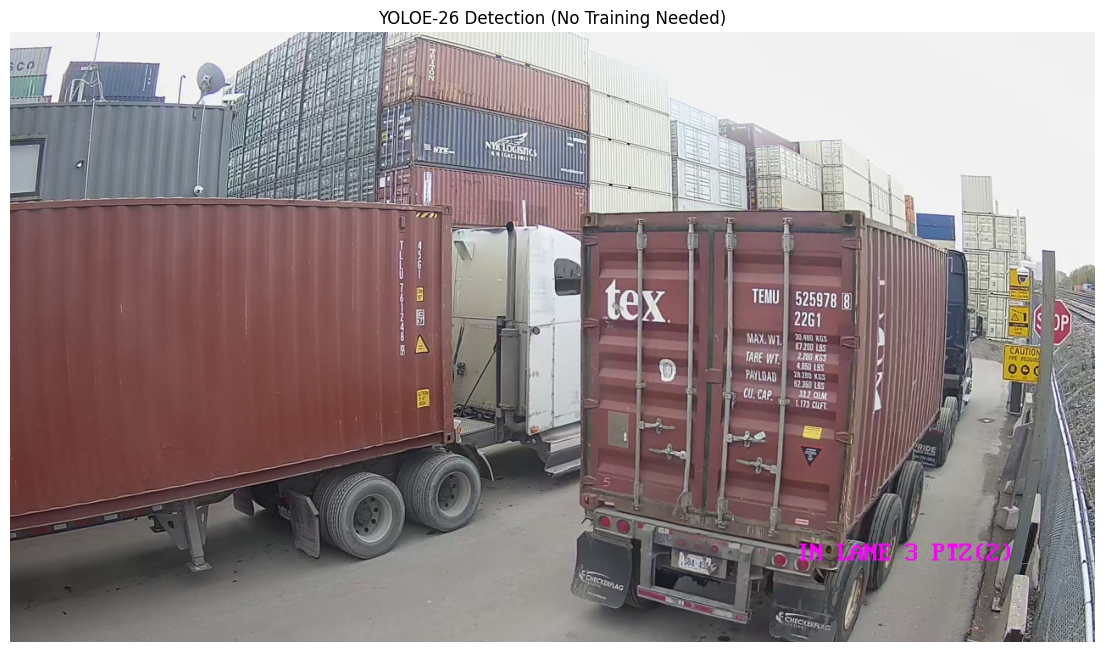

In [17]:

import cv2
import matplotlib.pyplot as plt
import os
from ultralytics import YOLOE
from ultralytics import YOLO
# ================== CONFIG ==================
image_path = r'C:\Users\Admin\Downloads\projects\vehicle_plate_detection\Dataset_preparation\data\output_frames\IN_LANE_3_PTZ(2)_NVR_20260429094351_20260429114352_1872780\frame_0106_01m_45s.jpg'

output_dir = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "yoloe26_detected.jpg")
# ===========================================

# Load YOLOE-26 model
print("Loading YOLOE-26 (Open Vocabulary Model)...")
model = YOLO("yoloe-26x-seg.pt")   # Try s, m, or l version

# Define what you want to detect (text prompts)
desired_classes = [
    "container_number" 
             # helpful for context
]

# This is the important part for YOLOE
model.set_classes(desired_classes)

# Run detection
print("Running detection...")
results = model(image_path, conf=0.25, verbose=False)

# Get annotated image
annotated_img = results[0].plot()

# Save result
cv2.imwrite(output_path, annotated_img)
print(f"✅ Saved: {output_path}")

# Display in Jupyter
annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(14, 9))
plt.imshow(annotated_rgb)
plt.title("YOLOE-26 Detection (No Training Needed)")
plt.axis('off')
plt.show()

✅ Saved: C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames\yoloe-26x_segmentation.jpg


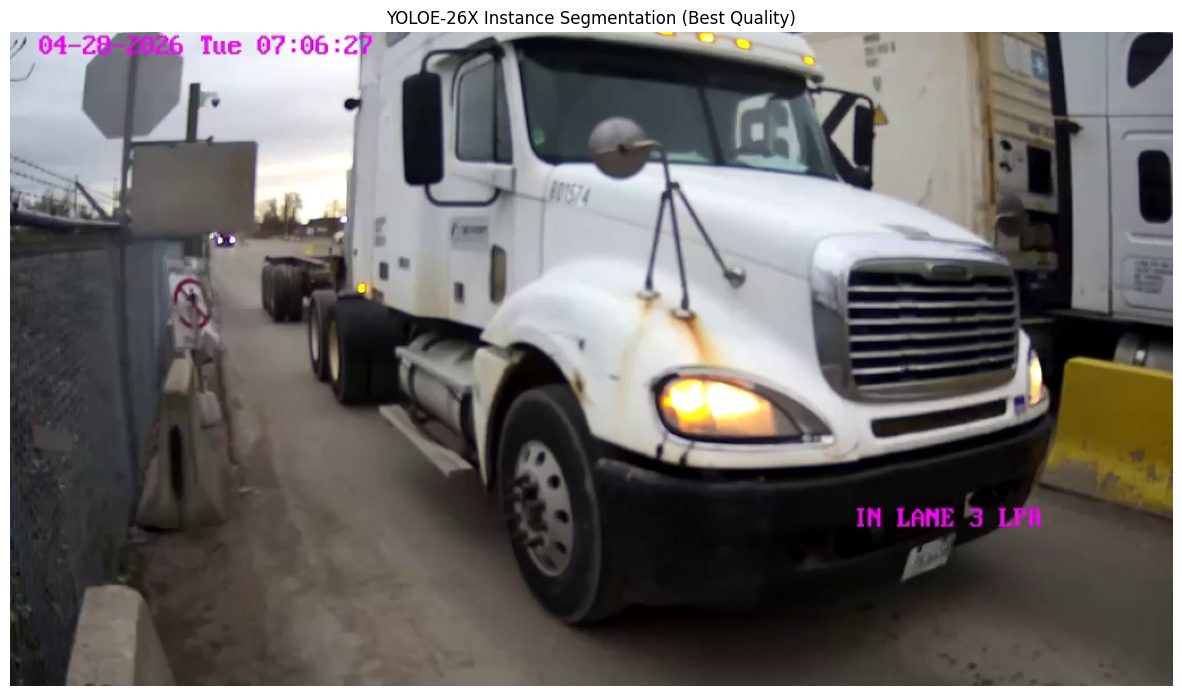

In [16]:
from ultralytics import YOLOE
import cv2
import os
import matplotlib.pyplot as plt

# ================== CONFIG ==================
image_path =r'C:\Users\Admin\Downloads\projects\vehicle_plate_detection\input_frames\frame_0002_00m_10s.jpg'

output_dir = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "yoloe-26x_segmentation.jpg")
# ===========================================

# Load the powerful YOLOE-26X model
model = YOLOE("yoloe-26x-seg.pt")

# Define your custom classes (unseen classes supported)
desired_classes = [
    "number_plate",
]

model.set_classes(desired_classes)

# Run inference
results = model(
    image_path, 
    conf=0.12,      # Very low for small objects like license plate
    iou=0.45,
    verbose=False
)

# Plot with instance segmentation masks
annotated_img = results[0].plot(
    masks=True,
    boxes=True,
    labels=True,
    conf=True,
    line_width=2
)

cv2.imwrite(output_path, annotated_img)
print(f"✅ Saved: {output_path}")

# Display
annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 10))
plt.imshow(annotated_rgb)
plt.title("YOLOE-26X Instance Segmentation (Best Quality)")
plt.axis('off')
plt.show()

Loading YOLOv11 model...
Running detection...
✅ Detection saved: C:\Users\Admin\Downloads\projects\vehicle_plate_detection\results\yolo11_detected.jpg


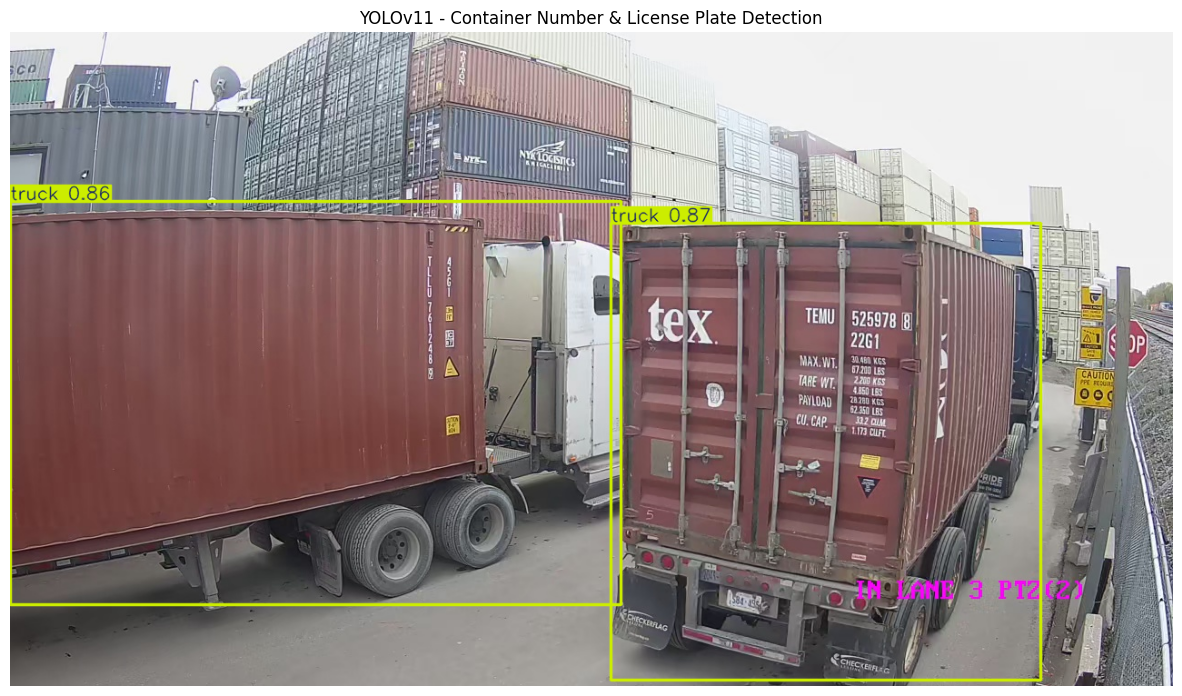


Detections:
1: truck | Confidence: 0.874
2: truck | Confidence: 0.857


In [9]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

# ========================= CONFIG =========================
image_path = r'C:\Users\Admin\Downloads\projects\vehicle_plate_detection\Dataset_preparation\data\output_frames\IN_LANE_3_PTZ(2)_NVR_20260429094351_20260429114352_1872780\frame_0106_01m_45s.jpg'

output_dir = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "yolo11_detected.jpg")

# Path to your trained model (change this after training)
model_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\yolo11n.pt"          # ← Put your trained model here
# =========================================================

# Load YOLOv11 model
print("Loading YOLOv11 model...")
model = YOLO(model_path)   # or "yolo11m.pt" for pre-trained

# Run detection
print("Running detection...")
results = model(
    image_path,
    conf=0.35,          # confidence threshold
    iou=0.45,
    verbose=False
)

# Get annotated image
annotated_img = results[0].plot(line_width=2, font_size=18)

# Save result
cv2.imwrite(output_path, annotated_img)
print(f"✅ Detection saved: {output_path}")

# ========================= DISPLAY =========================
annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 10))
plt.imshow(annotated_rgb)
plt.title("YOLOv11 - Container Number & License Plate Detection")
plt.axis('off')
plt.show()

# ========================= PRINT DETECTIONS =========================
print("\nDetections:")
for i, box in enumerate(results[0].boxes):
    cls_name = results[0].names[int(box.cls)]
    conf = float(box.conf)
    print(f"{i+1}: {cls_name} | Confidence: {conf:.3f}")

In [ ]:
from ultralytics import YOLO
import cv2
import os

# ========================= CONFIG =========================
image_path = r'C:\Users\Admin\Downloads\projects\vehicle_plate_detection\Dataset_preparation\data\output_frames\IN_LANE_3_PTZ(2)_NVR_20260429094351_20260429114352_1872780\frame_0106_01m_45s.jpg'

output_dir = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\results"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "yolo11_detected.jpg")
# =======================================================

# Load the model
model = YOLO("yolo11m.pt")        # Options: yolo11n.pt, yolo11s.pt, yolo11m.pt, yolo11l.pt

# Run inference on single image (or list of images)
results = model(image_path, conf=0.35, iou=0.45, verbose=False)

# Process results
for result in results:
    boxes = result.boxes       # Bounding boxes
    # masks = result.masks     # Uncomment if using segmentation model
    # probs = result.probs     # For classification

    # Show on screen
    result.show()

    # Save the result
    result.save(filename=output_path)
    print(f"✅ Result saved to: {output_path}")

    # Optional: Print detected objects
    print("\nDetected Objects:")
    for i, box in enumerate(boxes):
        cls_id = int(box.cls)
        class_name = result.names[cls_id]
        confidence = float(box.conf)
        print(f"{i+1}: {class_name} → {confidence:.2f} confidence")

ImportError: cannot import name 'YOLOvv11' from 'ultralytics' (c:\Users\Admin\Downloads\projects\vehicle_plate_detection\plateflow-env\Lib\site-packages\ultralytics\__init__.py)

In [ ]:
from ultralytics import YOLOvv11

model = YOLOvv11.from_pretrained("morsetechlab/yolov11-license-plate-detection")
source = 'http://images.cocodataset.org/val2017/000000039769.jpg'
model.predict(source=source, save=True)

Loading License Plate Model...


FileNotFoundError: [Errno 2] No such file or directory: 'license-plate-finetune-v1l.pt'

In [3]:
from ultralytics import SAM
import cv2
import os
import matplotlib.pyplot as plt

# ================== CONFIG ==================
image_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\input_frames\frame_0011_00m_50s.jpg"
output_dir = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "sam2_segmentation.jpg")
# ===========================================

# Load SAM2 model (first time will download automatically)
model = SAM("sam2.1_b.pt")        # Options: sam2.1_t.pt, sam2.1_s.pt, sam2.1_b.pt, sam2.1_l.pt

# Option 1: Segment Everything (no prompt needed)
results = model(image_path, verbose=False)

# Option 2: Use bounding box from YOLO as prompt (Much better for your use case)
# results = model(image_path, bboxes=[x1, y1, x2, y2])   # Example

# Plot results
annotated_img = results[0].plot(
    masks=True,
    boxes=False,      # Set True if you want boxes
    labels=True
)

cv2.imwrite(output_path, annotated_img)
print(f"✅ Saved: {output_path}")

# Show image
annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 10))
plt.imshow(annotated_rgb)
plt.title("SAM2 Instance Segmentation")
plt.axis('off')
plt.show()

FileNotFoundError: C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\input_frames\frame_0011_00m_50s.jpg does not exist

In [ ]:
# ================================
# SAM2 Single Image Segmentation
# ================================

from ultralytics import SAM
import cv2
import os
import matplotlib.pyplot as plt

# -------- CONFIG --------
image_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\input_frames\frame_0011_00m_50s.jpg"
model_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\sam2.1_b.pt"   # or just "sam2.1_b.pt" if in same folder

output_dir = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "sam2_output.jpg")
# ------------------------

def main():
    print("🚀 Loading SAM2 model...")
    model = SAM(model_path)

    print("📷 Reading image...")
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found: {image_path}")

    # -------- RUN SAM2 --------
    print("🧠 Running segmentation...")
    
    # Option 1: Segment everything
    results = model(image_path, verbose=False)

    # Option 2 (better): use bounding box (uncomment if needed)
    # results = model(image_path, bboxes=[[x1, y1, x2, y2]])

    # -------- VISUALIZE --------
    print("🎨 Creating output image...")
    annotated_img = results[0].plot(
        masks=True,
        boxes=False,
        labels=True
    )

    # Save output
    cv2.imwrite(output_path, annotated_img)
    print(f"✅ Saved output at: {output_path}")

    # Display image
    annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_rgb)
    plt.title("SAM2 Segmentation Result")
    plt.axis("off")
    plt.show()


if __name__ == "__main__":
    main()

In [ ]:
from ultralytics import SAM
import cv2
import os
import matplotlib.pyplot as plt

# -------- CONFIG --------
image_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\input_frames\frame_0011_00m_50s.jpg"
output_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames\sam2_fast.jpg"

# -------- LOAD MODEL (SMALL) --------
model = SAM("sam2.1_t.pt")   # 🔥 FAST

# -------- OPTIONAL: RESIZE IMAGE --------
img = cv2.imread(image_path)
img = cv2.resize(img, (640, 640))   # ⚡ faster

# -------- TARGETED SEGMENTATION --------
# Adjust bbox to plate area
bbox = [[300, 350, 600, 550]]

results = model(img, bboxes=bbox)

# -------- VISUALIZE --------
annotated = results[0].plot(masks=True, boxes=True)

cv2.imwrite(output_path, annotated)

plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title("Targeted SAM2 Segmentation")
plt.axis("off")
plt.show()

In [ ]:
from ultralytics import YOLO

# Load model
model = YOLO("yolov8n-seg.pt")

# Run inference
results = model(r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\input_frames\frame_0001_00m_00s.jpg")

# Save the annotated image (first result)
results[0].save(r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames\annotated_image.jpg")  # specify your filename

In [ ]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt

# CONFIG
image_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\input_frames\frame_0011_00m_50s.jpg"
output_dir = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "yolo26_segmentation.jpg")

model = YOLO("yolo26m-seg.pt")   # Change to yolo26n-seg.pt or yolo26s-seg.pt if slow

results = model(image_path, conf=0.25, verbose=False)

annotated_img = results[0].plot(masks=True, boxes=True, labels=True, conf=True)

cv2.imwrite(output_path, annotated_img)
print(f"✅ Saved: {output_path}")

annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 10))
plt.imshow(annotated_rgb)
plt.title("YOLO26m Instance Segmentation")
plt.axis('off')
plt.show()

In [ ]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt

# ================== CONFIG ==================
image_path = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\input_frames\frame_0011_00m_50s.jpg"
output_dir = r"C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\output_frames"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "yolo26_segmentation.jpg")
# ===========================================

model = YOLO("yolo")

# ====================== CLASS FILTERING ======================
# Show all available classes
print("Available Classes:")
for idx, name in model.names.items():
    print(f"{idx}: {name}")

# Filter to only classes you care about (example)
wanted_classes = [2, 3, 5, 7]   # car, motorcycle, bus, truck

# Run inference with class filter
results = model(
    image_path, 
    conf=0.25, 
    iou=0.45,
    classes=wanted_classes,   # ← This is how you "define" classes here
    verbose=False
)

# Plot with masks
annotated_img = results[0].plot(
    masks=True, 
    boxes=True, 
    labels=True, 
    conf=True,
    line_width=2
)

cv2.imwrite(output_path, annotated_img)
print(f"✅ Saved: {output_path}")

# Display
annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(15, 10))
plt.imshow(annotated_rgb)
plt.title("YOLO26m Instance Segmentation - Filtered Classes")
plt.axis('off')
plt.show()

In [ ]:
# First install dependencies
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install detectron2 -f https://dl.fbaipublicfiles.com/detectron2/wheels/cu121/torch2.4/index.html

In [ ]:
import sys
print(sys.executable)

In [ ]:
VEHICLE_MODEL = 'yolo11s.pt'                    # Pretrained on COCO (vehicles)
PLATE_MODEL = 'yolov11-license-plate.pt'        # ← Pre-trained for plates

In [ ]:
import os
from ultralytics import YOLO

os.makedirs('models', exist_ok=True)
os.makedirs('output', exist_ok=True)

plate_model_path = 'models/yolov11_license_plate.pt'

# ====================== MANUAL DOWNLOAD INSTRUCTIONS ======================
if not os.path.exists(plate_model_path):
    print("📥 Pre-trained model not found.")
    print("🔽 Please download it manually (one-time only):")
    print("\n1. Click this link:")
    print("   https://huggingface.co/morsetechlab/yolov11-license-plate-detection/resolve/main/license-plate-finetune-v1l.pt")
    print("\n2. Download the file (it's about 51 MB)")
    print("3. Rename it to: yolov11_license_plate.pt")
    print("4. Move it to the 'models' folder in your project")
    print("\n⏳ After downloading, run this cell again.")
    
    # Optional: Try direct download using Python (sometimes works better)
    try:
        import urllib.request
        url = "https://huggingface.co/morsetechlab/yolov11-license-plate-detection/resolve/main/license-plate-finetune-v1l.pt"
        print("\nTrying automatic download...")
        urllib.request.urlretrieve(url, plate_model_path)
        print("✅ Automatic download successful!")
    except:
        print("❌ Automatic download failed. Please download manually.")
else:
    print("✅ Pre-trained plate model found!")

# ====================== LOAD MODELS ======================
print("\n🚀 Loading models...")

vehicle_model = YOLO('yolo11s.pt')                    # Pretrained for vehicles
plate_model = YOLO(plate_model_path)                  # Pretrained for plates

reader = easyocr.Reader(['en'], gpu=True)

print("✅ All models loaded successfully! Ready to run detection.")

In [ ]:
VIDEO_SOURCE = r'C:\Users\Admin\Downloads\projects\vehicle_plate_detection\data\sample.mp4'

OUTPUT_VIDEO = 'output/plateflow_output.mp4'

# Confidence
VEHICLE_CONF = 0.5
PLATE_CONF = 0.4

VEHICLE_CLASSES = [2, 3, 5, 7]

print("✅ Configuration Updated - Using your sample.mp4")
print(f"Video Path: {VIDEO_SOURCE}")

In [ ]:
import cv2
from IPython.display import clear_output

# ====================== MAIN DETECTION ======================

cap = cv2.VideoCapture(VIDEO_SOURCE)

if not cap.isOpened():
    print("❌ Error: Cannot open video!")
    print("Check if the file exists at:", VIDEO_SOURCE)
else:
    print(f"✅ Video loaded successfully!")
    print(f"🎥 Processing: {VIDEO_SOURCE}")

frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS)) or 30
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
print(f"📊 Auto-detected FPS: {fps}")
print(f"📏 Resolution: {frame_width}x{frame_height}")
print(f"🔢 Total Frames: {total_frames}")
# Create output folder
os.makedirs('output', exist_ok=True)

# Video Writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (frame_width, frame_height))

frame_count = 0

print("🚀 Starting detection... (Press 'q' in the window to stop)")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # Vehicle Detection
    vehicle_results = vehicle_model(frame, 
                                    conf=VEHICLE_CONF, 
                                    classes=VEHICLE_CLASSES, 
                                    verbose=False)

    for vehicle in vehicle_results:
        for v_box in vehicle.boxes:
            vx1, vy1, vx2, vy2 = map(int, v_box.xyxy[0])

            cv2.rectangle(frame, (vx1, vy1), (vx2, vy2), (255, 165, 0), 2)
            cv2.putText(frame, "Vehicle", (vx1, vy1-10), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 165, 0), 2)

            vehicle_crop = frame[vy1:vy2, vx1:vx2]
            if vehicle_crop.size == 0:
                continue

            # Plate Detection
            plate_results = plate_model(vehicle_crop, 
                                        conf=PLATE_CONF, 
                                        verbose=False)

            for plate in plate_results:
                for p_box in plate.boxes:
                    px1, py1, px2, py2 = map(int, p_box.xyxy[0])

                    abs_x1 = vx1 + px1
                    abs_y1 = vy1 + py1
                    abs_x2 = vx1 + px2
                    abs_y2 = vy1 + py2

                    plate_crop = frame[abs_y1:abs_y2, abs_x1:abs_x2]

                    if plate_crop.size > 0:
                        ocr_result = reader.readtext(plate_crop, detail=0, paragraph=True)
                        plate_text = ' '.join(ocr_result).upper() if ocr_result else "???"

                        cv2.rectangle(frame, (abs_x1, abs_y1), (abs_x2, abs_y2), (0, 255, 0), 3)
                        cv2.putText(frame, plate_text, (abs_x1, abs_y1-15),
                                   cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2)

    out.write(frame)

    if frame_count % 10 == 0:
        clear_output(wait=True)
        print(f"Processed frames: {frame_count} / Total")

cap.release()
out.release()

print(f"\n✅ Processing Complete!")
print(f"Output saved at: **output/plateflow_output.mp4**")

In [ ]:
import cv2
import os
from IPython.display import clear_output

# ====================== CONFIG ======================


TARGET_FRAMES = 60

# Your models (assumed already loaded)
# vehicle_model = ...
# plate_model = ...
# reader = EasyOCR reader

VEHICLE_CONF = 0.4
PLATE_CONF = 0.4
VEHICLE_CLASSES = [2, 3, 5, 7]  # car, bike, bus, truck (example)

# ====================== SETUP ======================

cap = cv2.VideoCapture(VIDEO_SOURCE)

if not cap.isOpened():
    print("❌ Error: Cannot open video!")
    exit()

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = int(cap.get(cv2.CAP_PROP_FPS)) or 30
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))

# Calculate step for ~60 frames
step = max(1, total_frames // TARGET_FRAMES)

print(f"🎥 Total frames: {total_frames}")
print(f"⚙️ Sampling every {step} frame (~60 frames)")

# Create folders
os.makedirs('output', exist_ok=True)
os.makedirs('frames', exist_ok=True)
os.makedirs('plates', exist_ok=True)

# Video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (frame_width, frame_height))

frame_count = 0
processed_count = 0

print("🚀 Starting processing...")

# ====================== MAIN LOOP ======================

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    # Skip frames (sampling)
    if frame_count % step != 0:
        continue

    processed_count += 1

    # ================= VEHICLE DETECTION =================
    vehicle_results = vehicle_model(
        frame,
        conf=VEHICLE_CONF,
        classes=VEHICLE_CLASSES,
        verbose=False
    )

    for vehicle in vehicle_results:
        for v_box in vehicle.boxes:
            vx1, vy1, vx2, vy2 = map(int, v_box.xyxy[0])

            cv2.rectangle(frame, (vx1, vy1), (vx2, vy2), (255, 165, 0), 2)
            cv2.putText(frame, "Vehicle", (vx1, vy1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 165, 0), 2)

            vehicle_crop = frame[vy1:vy2, vx1:vx2]
            if vehicle_crop.size == 0:
                continue

            # ================= PLATE DETECTION =================
            plate_results = plate_model(
                vehicle_crop,
                conf=PLATE_CONF,
                verbose=False
            )

            for plate in plate_results:
                for p_box in plate.boxes:
                    px1, py1, px2, py2 = map(int, p_box.xyxy[0])

                    abs_x1 = vx1 + px1
                    abs_y1 = vy1 + py1
                    abs_x2 = vx1 + px2
                    abs_y2 = vy1 + py2

                    plate_crop = frame[abs_y1:abs_y2, abs_x1:abs_x2]

                    if plate_crop.size > 0:

                        # Save plate crop
                        plate_filename = f"plates/plate_{processed_count}_{abs_x1}_{abs_y1}.jpg"
                        cv2.imwrite(plate_filename, plate_crop)

                        # OCR
                        ocr_result = reader.readtext(plate_crop, detail=0, paragraph=True)
                        plate_text = ' '.join(ocr_result).upper() if ocr_result else "???"

                        # Draw plate box
                        cv2.rectangle(frame, (abs_x1, abs_y1), (abs_x2, abs_y2), (0, 255, 0), 3)
                        cv2.putText(frame, plate_text, (abs_x1, abs_y1 - 15),
                                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # ================= SAVE OUTPUT =================

    # Save frame image
    frame_filename = f"frames/frame_{processed_count:03d}.jpg"
    cv2.imwrite(frame_filename, frame)

    # Save to output video
    out.write(frame)

    # Progress log
    if processed_count % 10 == 0:
        clear_output(wait=True)
        print(f"Processed {processed_count} / ~60 frames")

# ====================== CLEANUP ======================

cap.release()
out.release()

print("\n✅ Processing complete!")
print(f"🎥 Total frames in video: {total_frames}")
print(f"🧠 Frames processed: {processed_count}")
print("📁 Frames saved in: /frames")
print("🚘 Plates saved in: /plates")
print(f"🎬 Output video: {OUTPUT_VIDEO}")